In [2]:
import sys
import os

sys.path.insert(0, os.path.abspath('..'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc

from src.train import (
    load_featured_data, prepare_data,
    train_random_forest, train_xgboost, train_lightgbm,
    evaluate_model, save_model
)

sns.set_theme(style='whitegrid', font_scale=1.1)
print("All imports OK!")

All imports OK!


In [3]:
df = load_featured_data()
X_train, X_test, y_train, y_test, train_df, test_df = prepare_data(df)

print("\nTraining all 3 models...")
rf        = train_random_forest(X_train, y_train)
xgb_model = train_xgboost(X_train, y_train)
lgb_model = train_lightgbm(X_train, y_train)

print("\nAll models trained!")

  Loaded f1_features.csv  →  26,759 rows  60 cols

  Train: 9,904 rows  (1994–2019)
  Test:  2,139 rows  (2020–2024)

  Train podium rate: 14.2%
  Test  podium rate: 15.0%

Training all 3 models...

  Training Random Forest...
  Done!

  Training XGBoost...


/opt/anaconda3/envs/f1predictor/lib/python3.11/site-packages/xgboost/training.py:200: UserWarning: [10:34:35] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


  Done!

  Training LightGBM...
  Done!

All models trained!


In [4]:
rf_results  = evaluate_model(rf,        X_test, y_test, 'Random Forest')
xgb_results = evaluate_model(xgb_model, X_test, y_test, 'XGBoost')
lgb_results = evaluate_model(lgb_model, X_test, y_test, 'LightGBM')


  Random Forest
  ROC-AUC:   0.9449
  F1 Score:  0.6819
  Precision: 0.5547
  Recall:    0.8847

  Classification Report:
              precision    recall  f1-score   support

   No Podium       0.98      0.87      0.92      1818
      Podium       0.55      0.88      0.68       321

    accuracy                           0.88      2139
   macro avg       0.77      0.88      0.80      2139
weighted avg       0.91      0.88      0.89      2139


  XGBoost
  ROC-AUC:   0.9401
  F1 Score:  0.7067
  Precision: 0.6534
  Recall:    0.7695

  Classification Report:
              precision    recall  f1-score   support

   No Podium       0.96      0.93      0.94      1818
      Podium       0.65      0.77      0.71       321

    accuracy                           0.90      2139
   macro avg       0.81      0.85      0.82      2139
weighted avg       0.91      0.90      0.91      2139


  LightGBM
  ROC-AUC:   0.9374
  F1 Score:  0.6918
  Precision: 0.6263
  Recall:    0.7726

  Classificat

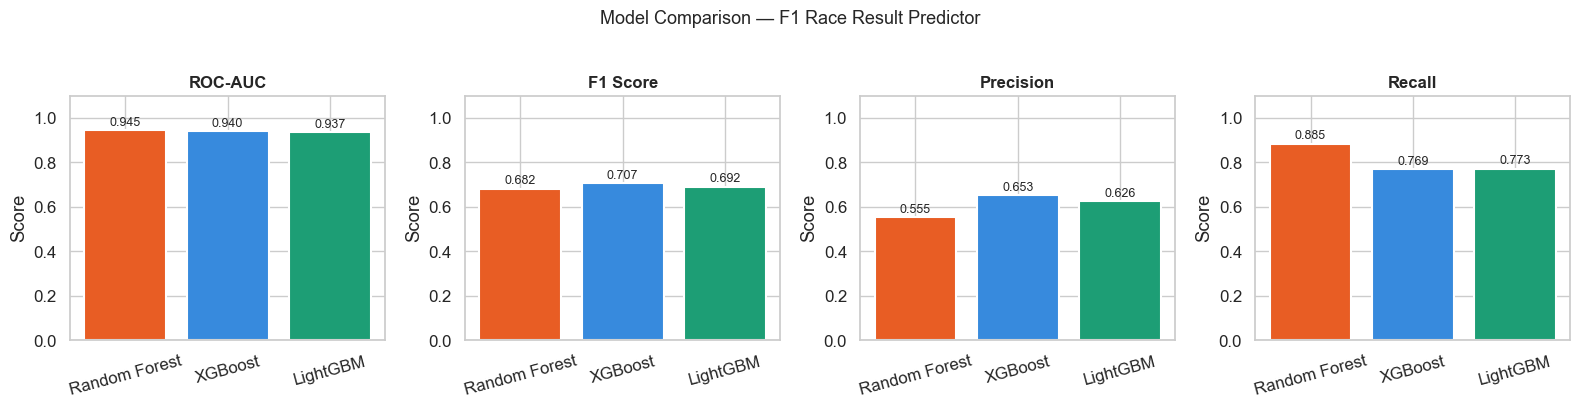

In [5]:
results = {
    'Model':     ['Random Forest', 'XGBoost', 'LightGBM'],
    'ROC-AUC':   [0.9449, 0.9401, 0.9374],
    'F1 Score':  [0.6819, 0.7067, 0.6918],
    'Precision': [0.5547, 0.6534, 0.6263],
    'Recall':    [0.8847, 0.7695, 0.7726],
}

results_df = pd.DataFrame(results)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
metrics = ['ROC-AUC', 'F1 Score', 'Precision', 'Recall']
colors  = ['#E85D24', '#378ADD', '#1D9E75']

for ax, metric in zip(axes, metrics):
    bars = ax.bar(results_df['Model'], results_df[metric],
                  color=colors, edgecolor='white', linewidth=1.5)
    ax.set_title(metric, fontsize=12, fontweight='bold')
    ax.set_ylim(0, 1.1)
    ax.set_ylabel('Score')
    for bar, val in zip(bars, results_df[metric]):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.02,
                f'{val:.3f}', ha='center', fontsize=9)
    ax.tick_params(axis='x', rotation=15)

plt.suptitle('Model Comparison — F1 Race Result Predictor',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

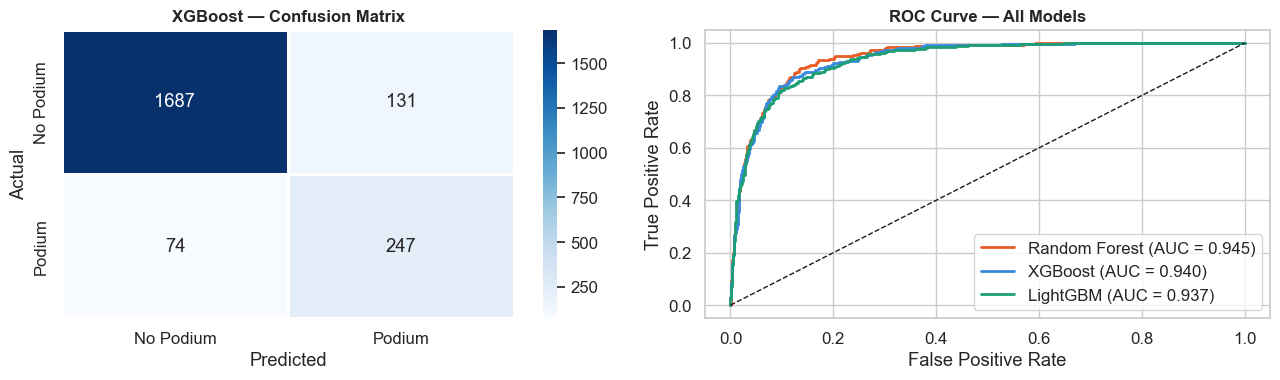

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Confusion matrix
cm = confusion_matrix(y_test, xgb_results['y_pred'])
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['No Podium', 'Podium'],
    yticklabels=['No Podium', 'Podium'],
    ax=axes[0], linewidths=1
)
axes[0].set_title('XGBoost — Confusion Matrix', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# ROC curve for all 3 models
for results, color, name in [
    (rf_results,  '#E85D24', 'Random Forest'),
    (xgb_results, '#378ADD', 'XGBoost'),
    (lgb_results, '#1D9E75', 'LightGBM'),
]:
    fpr, tpr, _ = roc_curve(y_test, results['y_pred_prob'])
    roc_auc     = auc(fpr, tpr)
    axes[1].plot(fpr, tpr, color=color, linewidth=2,
                 label=f'{name} (AUC = {roc_auc:.3f})')

axes[1].plot([0,1], [0,1], 'k--', linewidth=1)
axes[1].set_title('ROC Curve — All Models', fontsize=12, fontweight='bold')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend(loc='lower right')

plt.tight_layout()
plt.show()

In [7]:
save_model(rf,        'random_forest.pkl')
save_model(xgb_model, 'xgboost.pkl')
save_model(lgb_model, 'lightgbm.pkl')

print("\nAll models saved to models/ folder!")
print("Our final model: XGBoost (best F1 + Precision)")

  Saved → models/random_forest.pkl
  Saved → models/xgboost.pkl
  Saved → models/lightgbm.pkl

All models saved to models/ folder!
Our final model: XGBoost (best F1 + Precision)
